# Revenue Forecast: Model Ensemble
**Date:** April 2026
**Approach:** Three independent models → inverse-MAPE weighted ensemble

---
This notebook combines three independent forecasting methods into a single ensemble forecast
for monthly topline revenue (New Premium, Renewal Premium, Fee Revenue) over the next three years.
No single model is best — each captures different dynamics; averaging them reduces model-specific
bias and produces more robust predictions.

| | Model 1: Prophet | Model 2: STL + LSTM | Model 3: SARIMA |
|---|---|---|---|
| **Type** | Bayesian additive | Decomposition + neural | Classical statistical |
| **Trend** | Piecewise linear changepoints | Log-linear regression (STL) | Differencing (integrated) |
| **Seasonality** | Fourier terms | STL + Fourier residuals | Seasonal AR/MA lags |
| **Residuals** | Laplace / Normal | LSTM neural network | ARMA |
| **Strength** | Handles structural breaks | Captures non-linear patterns | Principled uncertainty, parsimonious |

**Contents:**
1. Data Loading & Common Setup
2. Model 1 — Prophet (results loaded from pre-computed output)
3. Model 2 — STL + LSTM Neural Network
4. Model 3 — SARIMA (auto-selected orders)
5. Model Comparison
6. Ensemble Forecast
7. Final Summary

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import STL
from pmdarima import auto_arima
from prophet import Prophet
import math

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.0,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_PATH = 'data/revenue_data.xlsx'  # proprietary dataset -- not included in repository

SERIES_CFG = [
    ('new_premium',     'New Premium',     '#1f77b4'),
    ('renewal_premium', 'Renewal Premium', '#2ca02c'),
    ('fees',            'Fee Revenue',     '#ff7f0e'),
]
MODEL_COLORS = {
    'Prophet': '#9467bd',
    'STL+LSTM': '#d62728',
    'SARIMA': '#8c564b',
    'Ensemble': '#000000',
}
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

PyTorch 2.11.0+cpu | Device: cpu


## 1. Data Loading & Common Setup

In [2]:
df_raw = pd.read_excel(DATA_PATH, sheet_name='Data')
df_raw['Effective_Date'] = pd.to_datetime(df_raw['Effective_Date'])
df_raw['month'] = df_raw['Effective_Date'].dt.to_period('M')

new_m = df_raw[df_raw['Is_Renewal?'] == 'No'].groupby('month')['direct_written_premium'].sum()
ren_m = df_raw[df_raw['Is_Renewal?'] == 'Yes'].groupby('month')['direct_written_premium'].sum()
fee_m = df_raw.groupby('month')['fees'].sum()

monthly = pd.DataFrame({'new_premium': new_m, 'renewal_premium': ren_m, 'fees': fee_m})
monthly.index = monthly.index.to_timestamp()
monthly['renewal_premium'] = monthly['renewal_premium'].fillna(0)
monthly['total_premium']   = monthly['new_premium'] + monthly['renewal_premium']
monthly['topline_revenue'] = monthly['total_premium'] + monthly['fees']

# Exclude partial months
monthly = monthly[(monthly.index >= '2018-10-01') & (monthly.index < '2025-07-01')]

# Common forecast horizon: Jul 2025 – Jun 2028 (36 months)
HIST_DATES   = monthly.index
FUTURE_DATES = pd.date_range(start='2025-07-01', periods=36, freq='MS')
N_HIST = len(monthly)

print(f"Training data: {N_HIST} months  ({HIST_DATES[0].strftime('%b %Y')} to {HIST_DATES[-1].strftime('%b %Y')})")
print(f"Forecast:      36 months  ({FUTURE_DATES[0].strftime('%b %Y')} to {FUTURE_DATES[-1].strftime('%b %Y')})")
monthly.tail(3)

Training data: 81 months  (Oct 2018 to Jun 2025)
Forecast:      36 months  (Jul 2025 to Jun 2028)


,new_premium,renewal_premium,fees,total_premium,topline_revenue
month,,,,,
2025-04-01,2.484967e+07,2.042946e+07,268426.6236,4.527913e+07,4.554756e+07
2025-05-01,4.223807e+07,2.320421e+07,405812.9984,6.544227e+07,6.584808e+07
2025-06-01,3.471270e+07,1.575409e+07,578039.3300,5.046679e+07,5.104483e+07


## 2. Model 1 — Prophet (Facebook/Meta)

Prophet is a Bayesian additive regression model that decomposes a time series into:
- **Trend**: piecewise linear or logistic growth, automatically detecting changepoints
- **Seasonality**: Fourier-series approximation of annual and weekly cycles
- **Holiday effects**: optional one-off event regressors

| Setting | New / Renewal Premium | Fee Revenue |
|---|---|---|
| **Training window** | Jun 2020 – Jun 2025 (60 months) | Dec 2023 – Jun 2025 (19 months) |
| **Winsorization** | 2.5% / 97.5% | 5% / 95% |
| **Growth mode** | Linear | Logistic (cap = 2× last actual) |
| **Changepoints** | n=10, prior scale=0.05 | n=10, prior scale=0.05 |
| **Yearly seasonality** | Custom Fourier, order=8 | Borrowed from new-premium model (×0.5) |
| **Regressor** | `policy_count` (held constant) | `policy_count` + `fee_spike` indicator |

In [3]:
# ── Prophet data prep ──────────────────────────────────────────────────────────
PREM_TRAIN_START = pd.Timestamp('2020-06-01')
FEES_TRAIN_START = pd.Timestamp('2023-12-01')

# Policy counts per segment — used as a Prophet regressor
new_pol_raw = df_raw[df_raw['Is_Renewal?'] == 'No'].groupby('month')['f'].count()
ren_pol_raw = df_raw[df_raw['Is_Renewal?'] == 'Yes'].groupby('month')['f'].count()
tot_pol_raw = df_raw.groupby('month')['f'].count()
new_pol_raw.index = new_pol_raw.index.to_timestamp()
ren_pol_raw.index = ren_pol_raw.index.to_timestamp()
tot_pol_raw.index = tot_pol_raw.index.to_timestamp()
monthly['new_pol'] = new_pol_raw.reindex(monthly.index).fillna(0)
monthly['ren_pol'] = ren_pol_raw.reindex(monthly.index).fillna(0)
monthly['tot_pol'] = tot_pol_raw.reindex(monthly.index).fillna(0)

# Training slices
prem_tr = monthly[(monthly.index >= PREM_TRAIN_START) & (monthly.index < FUTURE_DATES[0])].copy()
fees_tr = monthly[(monthly.index >= FEES_TRAIN_START) & (monthly.index < FUTURE_DATES[0])].copy()

# Winsorize
def winsorize(s, lo=0.025, hi=0.975):
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))

prem_tr['new_w']  = winsorize(prem_tr['new_premium'])
prem_tr['ren_w']  = winsorize(prem_tr['renewal_premium'])
fees_tr['fees_w'] = winsorize(fees_tr['fees'], lo=0.05, hi=0.95)

print(f'Premium training: {prem_tr.index[0].strftime("%b %Y")} to {prem_tr.index[-1].strftime("%b %Y")}  ({len(prem_tr)} months)')
print(f'Fees training:    {fees_tr.index[0].strftime("%b %Y")} to {fees_tr.index[-1].strftime("%b %Y")}  ({len(fees_tr)} months)')

Premium training: Jun 2020 to Jun 2025  (61 months)
Fees training:    Dec 2023 to Jun 2025  (19 months)


In [4]:
# ── Fit Prophet: New Premium & Renewal Premium ─────────────────────────────────
def make_prem_pdf(df_tr, y_col, pol_col):
    return pd.DataFrame({
        'ds':           df_tr.index,
        'y':            np.log(df_tr[y_col]),
        'policy_count': df_tr[pol_col].astype(float).values,
    })

def fit_prophet_prem(pdf):
    m = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
        changepoint_prior_scale=0.05, seasonality_prior_scale=20.0,
        n_changepoints=10, interval_width=0.80,
    )
    m.add_seasonality(name='yearly', period=365.25, fourier_order=8)
    m.add_regressor('policy_count')
    m.fit(pdf)
    return m

pdf_new = make_prem_pdf(prem_tr, 'new_w', 'new_pol')
pdf_ren = make_prem_pdf(prem_tr, 'ren_w', 'ren_pol')

print('  Fitting New Premium...')
m_new = fit_prophet_prem(pdf_new)
print('  Fitting Renewal Premium...')
m_ren = fit_prophet_prem(pdf_ren)

def forecast_prem(model, df_tr, pol_col, y_col):
    last_pol    = float(df_tr[pol_col].iloc[-1])
    last_actual = df_tr[y_col].iloc[-1]
    fut = pd.DataFrame({'ds': FUTURE_DATES, 'policy_count': np.repeat(last_pol, 36)})
    return np.exp(model.predict(fut)['yhat'].values).clip(max=last_actual * 2.0)

fc_new_arr = forecast_prem(m_new, prem_tr, 'new_pol', 'new_w')
fc_ren_arr = forecast_prem(m_ren, prem_tr, 'ren_pol', 'ren_w')
print('  New and Renewal Premium forecasts complete.')

  Fitting New Premium...


21:50:02 - cmdstanpy - INFO - Chain [1] start processing


21:50:02 - cmdstanpy - INFO - Chain [1] done processing


21:50:02 - cmdstanpy - INFO - Chain [1] start processing


21:50:02 - cmdstanpy - INFO - Chain [1] done processing


  Fitting Renewal Premium...


  New and Renewal Premium forecasts complete.


In [5]:
# ── Fit Prophet: Fees (logistic + borrowed seasonality) ────────────────────────
fees_last  = fees_tr['fees'].iloc[-1]
fees_cap   = fees_last * 2.0
fees_floor = fees_tr['fees'].iloc[0] * 0.5

fees_tr = fees_tr.copy()
fees_tr['fee_spike'] = fees_tr.index.isin([pd.Timestamp('2025-05-01')]).astype(float)

fees_pdf = pd.DataFrame({
    'ds':           fees_tr.index,
    'y':            np.log(fees_tr['fees_w']),
    'policy_count': fees_tr['tot_pol'].astype(float).values,
    'fee_spike':    fees_tr['fee_spike'].values,
    'cap':          np.log(fees_cap),
    'floor':        np.log(fees_floor),
})

m_fees = Prophet(
    growth='logistic',
    seasonality_mode='additive',
    yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
    changepoint_prior_scale=0.05, seasonality_prior_scale=1.0, interval_width=0.80,
)
m_fees.add_regressor('policy_count')
m_fees.add_regressor('fee_spike')
print('  Fitting Fees...')
m_fees.fit(fees_pdf)

# Borrow yearly seasonal shape from new-premium model (scaled by 0.5)
fut_new_seas = pd.DataFrame({'ds': FUTURE_DATES,
                              'policy_count': np.repeat(float(prem_tr['new_pol'].iloc[-1]), 36)})
seasonal_fut = m_new.predict(fut_new_seas)['yearly'].values * 0.5

fees_fut = pd.DataFrame({
    'ds':           FUTURE_DATES,
    'policy_count': np.repeat(float(fees_tr['tot_pol'].iloc[-1]), 36),
    'fee_spike':    np.zeros(36),
    'cap':          np.log(fees_cap),
    'floor':        np.log(fees_floor),
})
fc_fees_raw = m_fees.predict(fees_fut)
fc_fees_arr = np.exp(fc_fees_raw['yhat'].values + seasonal_fut).clip(max=fees_cap)
print('  Fees forecast complete.')

# Assemble prophet_fore_aligned — used by comparison and ensemble sections
prophet_fore_aligned = pd.DataFrame({
    'new_premium':     fc_new_arr,
    'renewal_premium': fc_ren_arr,
    'fees':            fc_fees_arr,
}, index=FUTURE_DATES)
prophet_fore_aligned['total_premium']   = prophet_fore_aligned['new_premium'] + prophet_fore_aligned['renewal_premium']
prophet_fore_aligned['topline_revenue'] = prophet_fore_aligned['total_premium'] + prophet_fore_aligned['fees']

pa = prophet_fore_aligned.copy(); pa['year'] = pa.index.year
ann_p = pa.groupby('year')[['new_premium','renewal_premium','fees','topline_revenue']].sum()
print()
print('Prophet Annual Forecast:')
print(ann_p.map(lambda x: f'${x/1e6:.1f}M').to_string())

21:50:02 - cmdstanpy - INFO - Chain [1] start processing


21:50:02 - cmdstanpy - INFO - Chain [1] done processing


  Fitting Fees...


  Fees forecast complete.

Prophet Annual Forecast:
     new_premium renewal_premium    fees topline_revenue
year                                                    
2025     $176.4M         $101.8M   $2.3M         $280.6M
2026     $458.7M         $231.3M   $9.3M         $699.3M
2027     $573.9M         $269.6M  $12.4M         $855.9M
2028     $345.5M         $150.8M   $6.5M         $502.8M


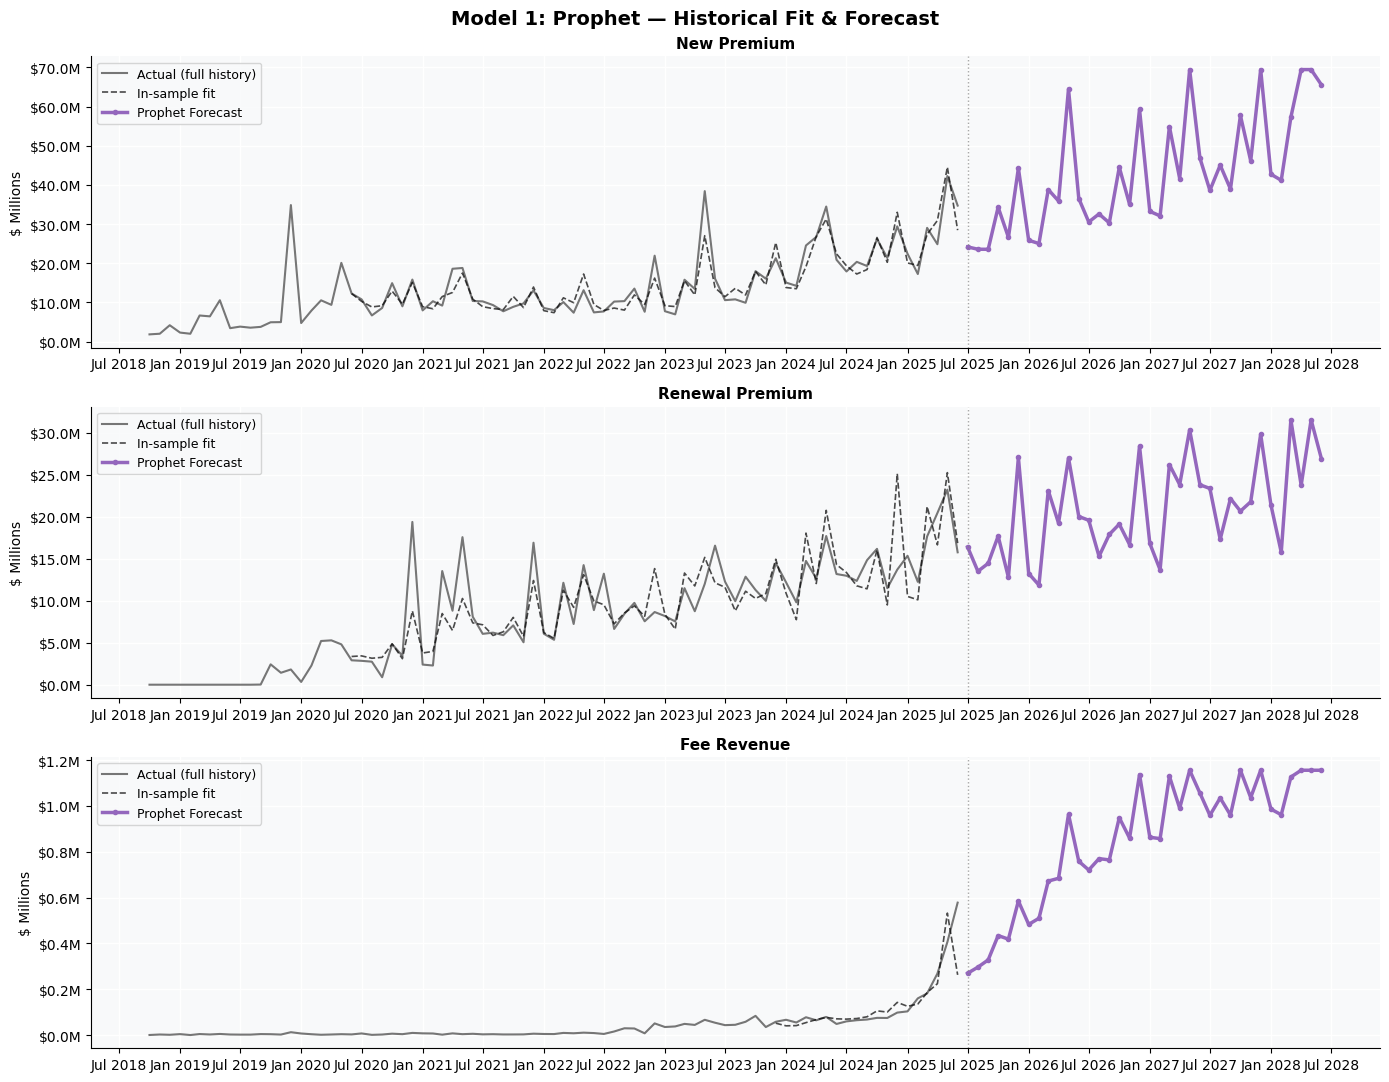

In [6]:
# ── Chart: Prophet in-sample fit + forecast ────────────────────────────────────
ins_new_vals  = np.exp(m_new.predict(pdf_new)['yhat'].values)
ins_ren_vals  = np.exp(m_ren.predict(pdf_ren)['yhat'].values)

# Fees in-sample: base model + borrowed seasonal on training dates
ins_fees_raw  = m_fees.predict(fees_pdf)
fut_new_ins   = pd.DataFrame({'ds': fees_tr.index,
                               'policy_count': np.repeat(float(prem_tr['new_pol'].iloc[-1]), len(fees_tr))})
ins_fees_vals = np.exp(ins_fees_raw['yhat'].values + m_new.predict(fut_new_ins)['yearly'].values * 0.5)

insample_cfg = {
    'new_premium':     (prem_tr.index, ins_new_vals),
    'renewal_premium': (prem_tr.index, ins_ren_vals),
    'fees':            (fees_tr.index,  ins_fees_vals),
}

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
fig.suptitle('Model 1: Prophet — Historical Fit & Forecast', fontsize=14, fontweight='bold')

for ax, (col, label, color) in zip(axes, SERIES_CFG):
    ins_dates, ins_vals = insample_cfg[col]
    ax.plot(HIST_DATES, monthly[col]/1e6, color='#555555', linewidth=1.5,
            label='Actual (full history)', alpha=0.8)
    ax.plot(ins_dates, ins_vals/1e6, color='black', linewidth=1.2,
            linestyle='--', label='In-sample fit', alpha=0.7)
    ax.plot(FUTURE_DATES, prophet_fore_aligned[col]/1e6,
            color=MODEL_COLORS['Prophet'], linewidth=2.5, marker='o', markersize=3,
            label='Prophet Forecast')
    ax.axvline(x=FUTURE_DATES[0], color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('$ Millions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model 2 — STL Decomposition + LSTM Neural Network

A two-stage hybrid model:
1. **STL** (Seasonal-Trend decomposition using Loess) separates each log-transformed series into
   trend + seasonal + residual components
2. A **log-linear trend** is fitted on a series-specific recent window and extrapolated 36 months
3. A **2-layer LSTM** (48 hidden units, 12-month lookback) learns the residual patterns using the
   same exogenous structure as Prophet: Fourier seasonality terms + `policy_count` regressor
   (segment-specific: new_pol / ren_pol / tot_pol). Fee Revenue additionally includes a
   `fee_spike` indicator for May 2025 (matching the Prophet fees model).
4. Forecast = `exp(trend + seasonal + LSTM_residual) − 1`, with residuals clipped to ±1.5σ.
   Policy count held constant at last observed value for the forecast horizon.

Training data: Oct 2018 – Jun 2025 (81 months)

In [7]:
LOOKBACK = 12
TREND_STARTS = {
    'new_premium':     '2020-01-01',
    'renewal_premium': '2020-10-01',
    'fees':            '2024-01-01',
}
# Policy count column per series — matches the regressor used in Prophet
POL_COLS = {
    'new_premium':     'new_pol',
    'renewal_premium': 'ren_pol',
    'fees':            'tot_pol',
}
# May 2025 fee-spike indicator — same one-off event regressor as Prophet fees model
SPIKE_MONTH = pd.Timestamp('2025-05-01')
SPIKE_IDX   = monthly.index.get_loc(SPIKE_MONTH) if SPIKE_MONTH in monthly.index else None

ALL_DATES = HIST_DATES.append(FUTURE_DATES)
N_TOTAL   = len(ALL_DATES)

def make_fourier(n, periods=(12, 6, 4, 3)):
    t = np.arange(n, dtype=float)
    return np.column_stack([f(2*math.pi*t/p) for p in periods for f in (np.sin, np.cos)])

FOURIER_ALL = make_fourier(N_TOTAL)   # (N_TOTAL, 8)

def build_feat_matrix(pol_hist, use_spike=False):
    """
    Build (N_TOTAL, F) feature matrix covering history + 36-month forecast.
      Fourier(8) + policy_count(1) [+ fee_spike(1) if use_spike]
    Policy count is normalised to mean≈1 and held constant at last-observed value
    for the forecast horizon (identical to Prophet's regressor assumption).
    """
    pol_norm = pol_hist / (pol_hist.mean() + 1e-8)
    pol_fore = np.full(36, pol_norm[-1])
    pol_all  = np.concatenate([pol_norm, pol_fore]).reshape(-1, 1)
    if use_spike:
        spike_hist = np.zeros(N_HIST)
        if SPIKE_IDX is not None:
            spike_hist[SPIKE_IDX] = 1.0
        spike_all = np.concatenate([spike_hist, np.zeros(36)]).reshape(-1, 1)
        return np.hstack([FOURIER_ALL, pol_all, spike_all]).astype(np.float32)
    return np.hstack([FOURIER_ALL, pol_all]).astype(np.float32)

def build_seqs(sc, feat_hist, lk=LOOKBACK):
    """sc: (N_HIST,) scaled residuals; feat_hist: (N_HIST, F) feature matrix"""
    X, y = [], []
    for i in range(lk, len(sc)):
        X.append(np.hstack([sc[i-lk:i].reshape(-1,1), feat_hist[i-lk:i]]))
        y.append(sc[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 48, 2, batch_first=True, dropout=0.15)
        self.fc   = nn.Linear(48, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

@torch.no_grad()
def lstm_predict(model, scaler, scaled, feat_all, start, n, clo, chi):
    """feat_all: (N_TOTAL, F) — spans both history and forecast dates."""
    model.eval()
    buf = list(scaled[start-LOOKBACK:start])
    preds = []
    for s in range(n):
        fi = start + s
        xv = np.array(buf[-LOOKBACK:], dtype=np.float32).reshape(-1, 1)
        xf = feat_all[fi-LOOKBACK:fi]
        p  = np.clip(model(torch.tensor(np.hstack([xv, xf])[np.newaxis])).item(), clo, chi)
        buf.append(p); preds.append(p)
    return scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()

def fit_stl_lstm(label, vals, trend_start, pol_col, use_spike=False, epochs=400, n_val=12):
    """
    pol_col   : monthly column for policy count (new_pol / ren_pol / tot_pol).
    use_spike : add May-2025 fee-spike indicator feature (fees only).
    """
    log_v    = np.log1p(vals)
    t_all    = np.arange(N_HIST, dtype=float)
    stl_res  = STL(pd.Series(log_v, index=HIST_DATES), period=12, robust=True).fit()
    seasonal = np.array(stl_res.seasonal)
    mask     = HIST_DATES >= pd.Timestamp(trend_start)
    coeffs   = np.polyfit(t_all[mask], log_v[mask], 1)
    trend_in = np.polyval(coeffs, t_all)
    resid    = log_v - trend_in - seasonal

    pol_hist = monthly[pol_col].fillna(0).values.astype(float)
    feat_all = build_feat_matrix(pol_hist, use_spike=use_spike)
    input_sz = 1 + feat_all.shape[1]   # lagged residual + F features

    scaler = MinMaxScaler(feature_range=(0,1))
    sc_r   = scaler.fit_transform(resid.reshape(-1,1)).flatten()
    X, y   = build_seqs(sc_r, feat_all[:N_HIST])
    n_tr   = len(X) - n_val
    loader = DataLoader(TensorDataset(torch.tensor(X[:n_tr]), torch.tensor(y[:n_tr])),
                        batch_size=16, shuffle=True)
    model  = LSTMModel(input_sz).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=8e-4)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    crit   = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            opt.zero_grad(); loss = crit(model(xb), yb)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()
        sched.step()

    clo = float(scaler.transform([[resid.mean()-1.5*resid.std()]])[0,0])
    chi = float(scaler.transform([[resid.mean()+1.5*resid.std()]])[0,0])

    fore_t = np.arange(N_HIST, N_HIST+36, dtype=float)
    MAX_FEE_MONTHLY_SLOPE = np.log(1.50) / 12
    if label == 'Fee Revenue' and coeffs[0] > MAX_FEE_MONTHLY_SLOPE:
        cap_intercept = log_v[-1] - MAX_FEE_MONTHLY_SLOPE * t_all[-1]
        trend_fo      = np.polyval([MAX_FEE_MONTHLY_SLOPE, cap_intercept], fore_t)
        print(f'  {label:20s}  fee trend capped: {math.exp(coeffs[0]*12)-1:.0%}/yr → 50%/yr')
    else:
        trend_fo = np.polyval(coeffs, fore_t)
    seasonal_fo = np.tile(seasonal[-12:], 3)
    in_r        = lstm_predict(model, scaler, sc_r, feat_all, LOOKBACK, N_HIST-LOOKBACK, clo, chi)
    in_lvl      = np.expm1(trend_in[LOOKBACK:] + seasonal[LOOKBACK:] + in_r)
    fore_r      = lstm_predict(model, scaler, sc_r, feat_all, N_HIST, 36, clo, chi)
    fore_lvl    = np.expm1(trend_fo + seasonal_fo + fore_r)
    mape        = np.mean(np.abs(vals[-n_val:]-in_lvl[-n_val:])/np.maximum(vals[-n_val:],1))*100
    cagr        = math.exp(coeffs[0]*12)-1
    spike_note  = '+spike' if use_spike else ''
    print(f'  {label:20s}  MAPE={mape:.1f}%  CAGR={cagr:.1%}/yr  features=Fourier+{pol_col}{spike_note}')
    return dict(forecast=fore_lvl, in_sample=in_lvl, in_sample_dates=HIST_DATES[LOOKBACK:],
                mape=mape, cagr=cagr)

print('STL+LSTM helpers defined. Training...')

STL+LSTM helpers defined. Training...


In [8]:
lstm_results = {}
for col, label, color in SERIES_CFG:
    lstm_results[col] = fit_stl_lstm(
        label, monthly[col].values.astype(float),
        TREND_STARTS[col], POL_COLS[col],
        use_spike=(col == 'fees'),
    )
print('STL+LSTM training complete.')

  New Premium           MAPE=32.0%  CAGR=23.5%/yr  features=Fourier+new_pol


  Renewal Premium       MAPE=13.5%  CAGR=25.7%/yr  features=Fourier+ren_pol


  Fee Revenue           fee trend capped: 285%/yr → 50%/yr
  Fee Revenue           MAPE=36.6%  CAGR=285.5%/yr  features=Fourier+tot_pol+spike
STL+LSTM training complete.


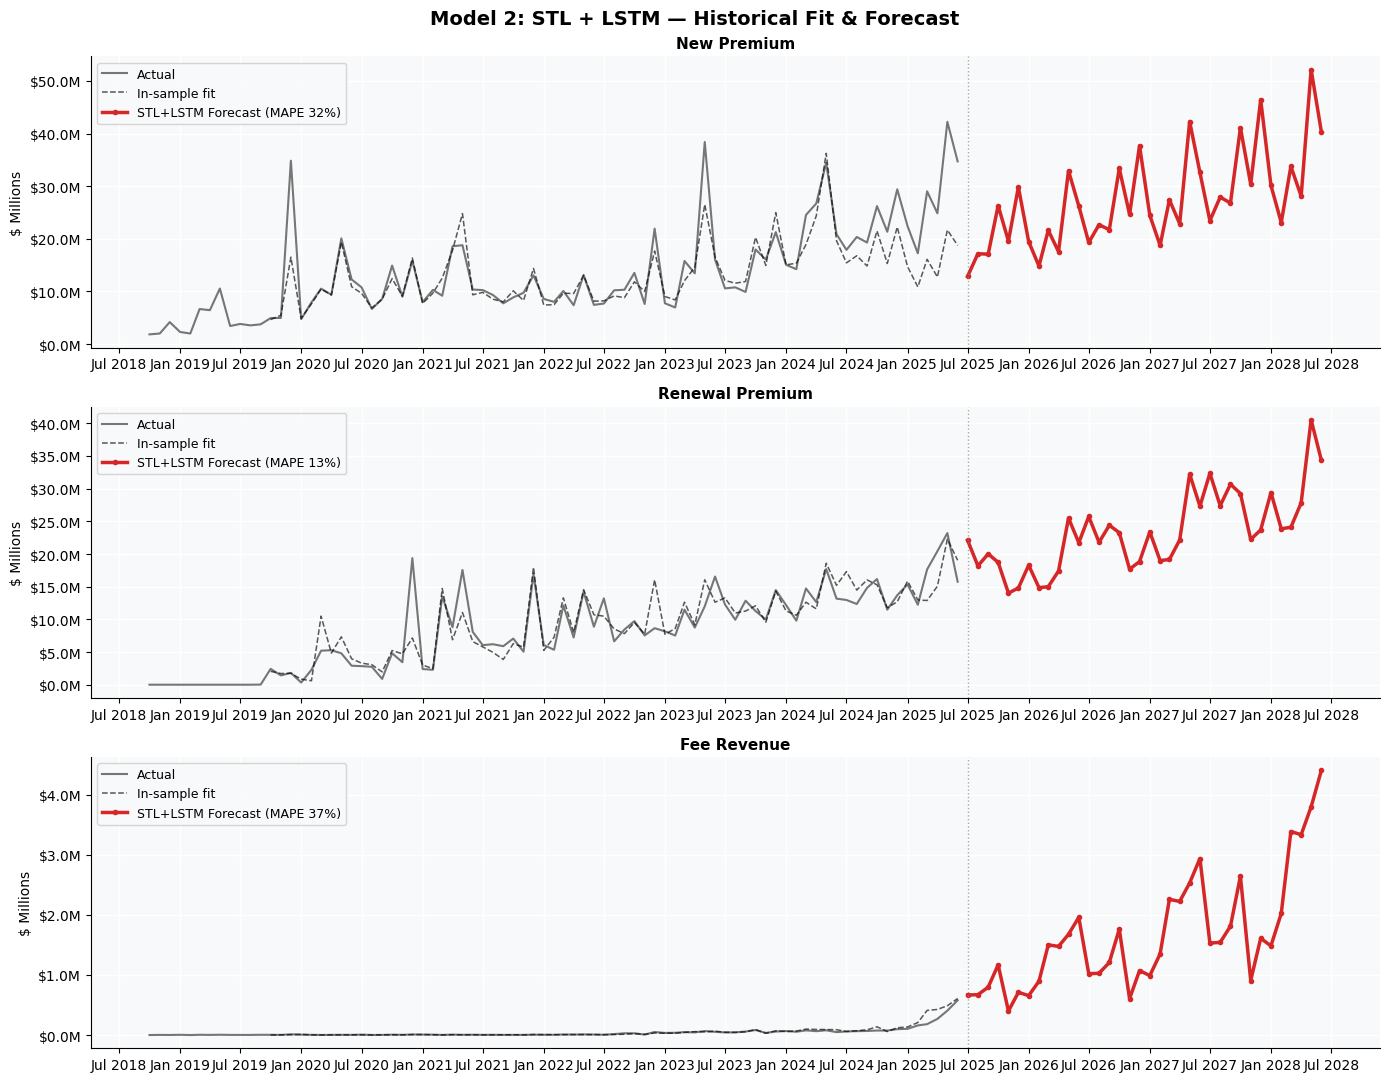

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
fig.suptitle('Model 2: STL + LSTM — Historical Fit & Forecast', fontsize=14, fontweight='bold')

for ax, (col, label, color) in zip(axes, SERIES_CFG):
    d = lstm_results[col]
    ax.plot(HIST_DATES, monthly[col]/1e6, color='#555555', linewidth=1.5, label='Actual', alpha=0.8)
    ax.plot(d['in_sample_dates'], d['in_sample']/1e6, color='black', linewidth=1.1,
            linestyle='--', label='In-sample fit', alpha=0.65)
    ax.plot(FUTURE_DATES, d['forecast']/1e6, color=MODEL_COLORS['STL+LSTM'], linewidth=2.5,
            marker='o', markersize=3, label=f'STL+LSTM Forecast (MAPE {d["mape"]:.0f}%)')
    ax.axvline(x=FUTURE_DATES[0], color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('$ Millions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model 3 — SARIMA (Seasonal ARIMA)

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is the classical econometric approach
to time series forecasting. Written as SARIMA(p,d,q)(P,D,Q)_m:
- **(p,d,q)**: non-seasonal AR order, differencing, MA order
- **(P,D,Q)_m**: seasonal AR, differencing, MA at period m=12 months

**Implementation:**
- `auto_arima` from `pmdarima` performs AIC-minimizing stepwise search over candidate orders
- All series modeled in **log space** (handles multiplicative seasonality naturally)
- Training windows trimmed per series to exclude startup-ramp distortion

**Fee Revenue — Fee Rate approach (STL + ARIMA on de-seasonalized trend):**
The client's fee revenue is structurally proportional to the total premium volume it processes —
fees are calculated as a percentage of premiums collected. Modeling raw fees directly conflates
this structural dependency with the underlying growth trend.

Instead, we model the **fee rate** = fees / total_premium, capturing the client's pricing policy
independent of premium volume, in a two-stage process:
1. **STL decomposition** of log(fee_rate): separates the seasonal pattern from the growth trend.
   With only 42 months of history (Jan 2022 – Jun 2025), the strong upward trend otherwise
   masks the seasonal component in a direct SARIMA fit.
2. **ARIMA on de-seasonalized series**: models the trend/residual component cleanly.
   Forecast trend is capped at 50%/yr (fee rate grew ~179%/yr historically — unsustainable).
   The last 12 months of seasonal pattern are tiled back over the 36-month forecast horizon.
3. **Final fees** = exp(trend_fore + seasonal_fore) × SARIMA total-premium forecast.
   Fees inherit month-to-month oscillation from both the fee_rate seasonal pattern and the
   seasonal variation already embedded in the premium forecasts above.

| Series | Training Window | Approach |
|---|---|---|
| New Premium | Oct 2018 – Jun 2025 (81 mo) | Standard SARIMA, m=12 |
| Renewal Premium | Oct 2020 – Jun 2025 (57 mo) | Standard SARIMA, m=12 |
| Fee Revenue | Jan 2022 – Jun 2025 (42 mo) | STL + ARIMA on fee_rate × SARIMA premium forecast |

In [10]:
# Training start dates — trim startup ramp that distorts ARIMA differencing
SARIMA_STARTS = {
    'new_premium':     None,          # full history (81 months)
    'renewal_premium': '2020-10-01',  # first full annual renewal cycle (57 months)
}
# Fees use a separate fee_rate model (below) — not in the main SARIMA loop

def fit_sarima(label, vals, train_start=None, pol_vals=None, n_val=12):
    """
    pol_vals: full-history (N_HIST,) policy count array — used as ARIMAX exogenous.
    Normalised to zero-mean/unit-variance; held constant at last value for forecast.
    Matches the policy_count regressor used in the Prophet model.
    """
    if train_start is not None:
        mask      = HIST_DATES >= pd.Timestamp(train_start)
        vals      = vals[mask]
        fit_dates = HIST_DATES[mask]
        pol_trim  = pol_vals[mask] if pol_vals is not None else None
        print(f'  Fitting SARIMA for {label}  ({fit_dates[0].strftime("%b %Y")} – {fit_dates[-1].strftime("%b %Y")}, {len(vals)} months)...')
    else:
        fit_dates = HIST_DATES
        pol_trim  = pol_vals
        print(f'  Fitting SARIMA for {label}...')

    log_v   = np.log1p(vals)
    train_v = log_v[:-n_val]
    val_v   = vals[-n_val:]

    # Build ARIMAX exogenous: normalised policy count, held constant at last value for forecast
    if pol_trim is not None:
        pol_n     = (pol_trim - pol_trim.mean()) / (pol_trim.std() + 1e-8)
        exog_tr   = pol_n[:-n_val].reshape(-1, 1)
        exog_vl   = pol_n[-n_val:].reshape(-1, 1)
        exog_full = pol_n.reshape(-1, 1)
        exog_fore = np.full((36, 1), pol_n[-1])
    else:
        exog_tr = exog_vl = exog_full = exog_fore = None

    model = auto_arima(
        train_v,
        exogenous=exog_tr,
        seasonal=True, m=12,
        stepwise=True, max_p=2, max_q=2,
        max_P=1, max_Q=1, max_d=2, max_D=1,
        information_criterion='aic', error_action='ignore',
        suppress_warnings=True, n_jobs=1,
    )
    exog_note = ' +policy_count' if pol_trim is not None else ''
    print(f'    Best order: {model.order}  seasonal: {model.seasonal_order}{exog_note}')

    val_log_pred = model.predict(n_periods=n_val, exogenous=exog_vl)
    val_pred     = np.expm1(val_log_pred)
    mape = np.mean(np.abs(val_v - val_pred) / np.maximum(val_v, 1)) * 100
    print(f'    Validation MAPE (last 12 mo): {mape:.1f}%')

    model_full = auto_arima(
        log_v,
        exogenous=exog_full,
        seasonal=True, m=12,
        start_p=model.order[0], start_q=model.order[2],
        start_P=model.seasonal_order[0], start_Q=model.seasonal_order[2],
        max_p=model.order[0]+1, max_q=model.order[2]+1,
        information_criterion='aic', error_action='ignore',
        suppress_warnings=True, n_jobs=1,
    )
    fc_log, conf_int = model_full.predict(n_periods=36, exogenous=exog_fore, return_conf_int=True)

    fc_lvl = np.expm1(fc_log)
    fc_lo  = np.expm1(conf_int[:, 0])
    fc_hi  = np.expm1(conf_int[:, 1])

    in_log = model_full.predict_in_sample(exogenous=exog_full)
    in_lvl = np.expm1(in_log)

    # Extract calendar-month seasonal factors via STL for use by the fee_rate model
    stl_for_seas = STL(pd.Series(log_v, index=fit_dates), period=12, robust=True).fit()
    seas_s = pd.Series(np.array(stl_for_seas.seasonal), index=fit_dates)
    seasonal_by_month = seas_s.groupby(seas_s.index.month).mean().to_dict()

    return dict(forecast=fc_lvl, forecast_lo=fc_lo, forecast_hi=fc_hi,
                in_sample=in_lvl, in_sample_dates=fit_dates[:len(in_lvl)],
                mape=mape, order=model.order, seasonal_order=model.seasonal_order,
                seasonal_by_month=seasonal_by_month)


def fit_sarima_fee_rate(fee_vals, new_prem_vals, ren_prem_vals,
                        pol_vals=None, prem_seasonal_by_month=None,
                        train_start='2022-01-01', n_val=12):
    """
    Model fee_rate = fees / total_premium with ARIMA on the de-seasonalized trend.

    Approach:
      1. Compute log(fee_rate) on the training window (Jan 2022 onwards)
      2. Apply multiplicative seasonal adjustment borrowed from new/renewal premium STL
         seasonal patterns (averaged, aligned by calendar month). Using 5+ years of
         premium history gives a more reliable seasonal pattern than the 3.5-year
         fee_rate history.
      3. Fit non-seasonal ARIMA on de-seasonalized log(fee_rate) with exogenous:
           policy_count (normalised tot_pol, matching Prophet fees regressor)
           fee_spike    (May 2025 one-off indicator, matching Prophet fees regressor)
      4. Forecast de-seasonalized trend, cap at 50%/yr, add premium seasonal back
      5. Multiply exp(trend_fore + seasonal_fore) × SARIMA total-premium forecast
    """
    mask      = HIST_DATES >= pd.Timestamp(train_start)
    fees_tr   = fee_vals[mask]
    new_tr    = new_prem_vals[mask]
    ren_tr    = ren_prem_vals[mask]
    fit_dates = HIST_DATES[mask]

    total_prem_tr = new_tr + ren_tr
    fee_rate      = fees_tr / total_prem_tr

    print(f'  Fitting ARIMA fee_rate  ({fit_dates[0].strftime("%b %Y")} – {fit_dates[-1].strftime("%b %Y")}, {len(fee_rate)} months)...')
    print(f'    Fee rate: {fee_rate[0]*100:.3f}% → {fee_rate[-1]*100:.3f}%'
          f'  (CAGR: {(fee_rate[-1]/fee_rate[0])**(12/len(fee_rate))-1:.0%}/yr)')

    log_fr = np.log(fee_rate)

    # Seasonal component: calendar-month factors averaged from new/renewal STL seasonal.
    # Aligned to training dates and forecast dates by calendar month number.
    if prem_seasonal_by_month is not None:
        seasonal      = np.array([prem_seasonal_by_month[d.month] for d in fit_dates])
        seasonal_fore = np.array([prem_seasonal_by_month[d.month] for d in FUTURE_DATES])
        val_seas      = np.array([prem_seasonal_by_month[d.month] for d in fit_dates[-n_val:]])
        seas_src      = 'premium seasonal'
    else:
        # Fallback: STL directly on fee_rate
        stl_res  = STL(pd.Series(log_fr, index=fit_dates), period=12, robust=True).fit()
        seasonal = np.array(stl_res.seasonal)
        seasonal_fore = np.tile(seasonal[-12:], 3)
        val_seas      = seasonal[-n_val:]
        seas_src      = 'fee_rate STL seasonal'

    deseason = log_fr - seasonal

    # ARIMAX exogenous — matches Prophet fees model exactly:
    #   Column 0: normalised policy count (tot_pol held constant at last value for forecast)
    #   Column 1: fee_spike indicator (1 for May 2025, 0 everywhere else incl. forecast)
    spike_hist = np.array([1.0 if d == pd.Timestamp('2025-05-01') else 0.0 for d in fit_dates])
    spike_fore = np.zeros(36)
    if pol_vals is not None:
        pol_tr    = pol_vals[mask]
        pol_n     = (pol_tr - pol_tr.mean()) / (pol_tr.std() + 1e-8)
        exog_tr   = np.column_stack([pol_n[:-n_val],        spike_hist[:-n_val]])
        exog_val  = np.column_stack([pol_n[-n_val:],         spike_hist[-n_val:]])
        exog_full = np.column_stack([pol_n,                  spike_hist])
        exog_fore = np.column_stack([np.full(36, pol_n[-1]), spike_fore])
        exog_note = ' +policy_count +fee_spike'
    else:
        exog_tr   = spike_hist[:-n_val].reshape(-1, 1)
        exog_val  = spike_hist[-n_val:].reshape(-1, 1)
        exog_full = spike_hist.reshape(-1, 1)
        exog_fore = spike_fore.reshape(-1, 1)
        exog_note = ' +fee_spike'

    model = auto_arima(
        deseason[:-n_val],
        exogenous=exog_tr,
        seasonal=False,
        stepwise=True, max_p=3, max_q=3, max_d=2,
        information_criterion='aic', error_action='ignore',
        suppress_warnings=True, n_jobs=1,
    )
    print(f'    Best ARIMA order: {model.order}{exog_note}  seasonal: {seas_src}')

    val_des_pred  = model.predict(n_periods=n_val, exogenous=exog_val)
    val_log_pred  = val_des_pred + val_seas
    val_rate_pred = np.exp(val_log_pred)
    val_prem      = total_prem_tr[-n_val:]
    val_fees      = fees_tr[-n_val:]
    val_pred      = val_rate_pred * val_prem
    mape = np.mean(np.abs(val_fees - val_pred) / np.maximum(val_fees, 1)) * 100
    print(f'    Validation MAPE (last 12 mo): {mape:.1f}%')

    model_full = auto_arima(
        deseason,
        exogenous=exog_full,
        seasonal=False,
        start_p=model.order[0], start_q=model.order[2],
        max_p=model.order[0]+1, max_q=model.order[2]+1,
        information_criterion='aic', error_action='ignore',
        suppress_warnings=True, n_jobs=1,
    )
    fc_des, conf_int = model_full.predict(n_periods=36, exogenous=exog_fore, return_conf_int=True)

    # Cap de-seasonalized trend at 50%/yr. Seasonal layer is added back after the cap
    # so the monthly oscillation is preserved within the capped growth envelope.
    MAX_LOG_MONTHLY = np.log(1.50) / 12
    max_log_fore    = deseason[-1] + MAX_LOG_MONTHLY * np.arange(1, 37)
    fc_des          = np.minimum(fc_des,         max_log_fore)
    conf_int[:, 0]  = np.minimum(conf_int[:, 0], max_log_fore)
    conf_int[:, 1]  = np.minimum(conf_int[:, 1], max_log_fore + 0.5)
    print(f'    Trend capped at 50%/yr; seasonal pattern borrowed from new/renewal premium models')

    fc_log_rate = fc_des + seasonal_fore
    fc_fee_rate = np.exp(fc_log_rate)
    fc_lo_rate  = np.exp(conf_int[:, 0] + seasonal_fore)
    fc_hi_rate  = np.exp(conf_int[:, 1] + seasonal_fore)

    total_prem_fore = sarima_results['new_premium']['forecast'] + sarima_results['renewal_premium']['forecast']
    fc_fees    = fc_fee_rate * total_prem_fore
    fc_fees_lo = fc_lo_rate  * total_prem_fore
    fc_fees_hi = fc_hi_rate  * total_prem_fore

    in_des      = model_full.predict_in_sample(exogenous=exog_full)
    in_log_rate = in_des + seasonal[:len(in_des)]
    in_fee_rate = np.exp(in_log_rate)
    in_fees     = in_fee_rate * total_prem_tr[:len(in_des)]

    return dict(forecast=fc_fees, forecast_lo=fc_fees_lo, forecast_hi=fc_fees_hi,
                in_sample=in_fees, in_sample_dates=fit_dates[:len(in_fees)],
                mape=mape, order=model.order, seasonal_order=(0, 0, 0, 0))


print('Fitting SARIMA models (ARIMAX with policy_count regressor)...')
sarima_results = {}
for col, label, _ in SERIES_CFG:
    if col == 'fees':
        # Average the calendar-month seasonal patterns from new/renewal (5+ years each)
        # and use them as the multiplicative seasonal adjustment for fees.
        new_sbm = sarima_results['new_premium']['seasonal_by_month']
        ren_sbm = sarima_results['renewal_premium']['seasonal_by_month']
        prem_seasonal_by_month = {m: (new_sbm[m] + ren_sbm[m]) / 2 for m in range(1, 13)}
        sarima_results['fees'] = fit_sarima_fee_rate(
            monthly['fees'].values.astype(float),
            monthly['new_premium'].values.astype(float),
            monthly['renewal_premium'].values.astype(float),
            pol_vals=monthly['tot_pol'].fillna(0).values.astype(float),
            prem_seasonal_by_month=prem_seasonal_by_month,
        )
    else:
        sarima_results[col] = fit_sarima(
            label, monthly[col].values.astype(float),
            train_start=SARIMA_STARTS.get(col),
            pol_vals=monthly[POL_COLS[col]].fillna(0).values.astype(float),
        )
print('\nSARIMA fitting complete.')

Fitting SARIMA models (ARIMAX with policy_count regressor)...
  Fitting SARIMA for New Premium...


    Best order: (2, 1, 2)  seasonal: (1, 0, 1, 12) +policy_count
    Validation MAPE (last 12 mo): 16.2%


  Fitting SARIMA for Renewal Premium  (Oct 2020 – Jun 2025, 57 months)...


    Best order: (0, 1, 1)  seasonal: (1, 0, 0, 12) +policy_count
    Validation MAPE (last 12 mo): 9.9%


  Fitting ARIMA fee_rate  (Jan 2022 – Jun 2025, 42 months)...
    Fee rate: 0.031% → 1.145%  (CAGR: 179%/yr)


    Best ARIMA order: (0, 1, 1) +policy_count +fee_spike  seasonal: premium seasonal
    Validation MAPE (last 12 mo): 54.1%


    Trend capped at 50%/yr; seasonal pattern borrowed from new/renewal premium models

SARIMA fitting complete.


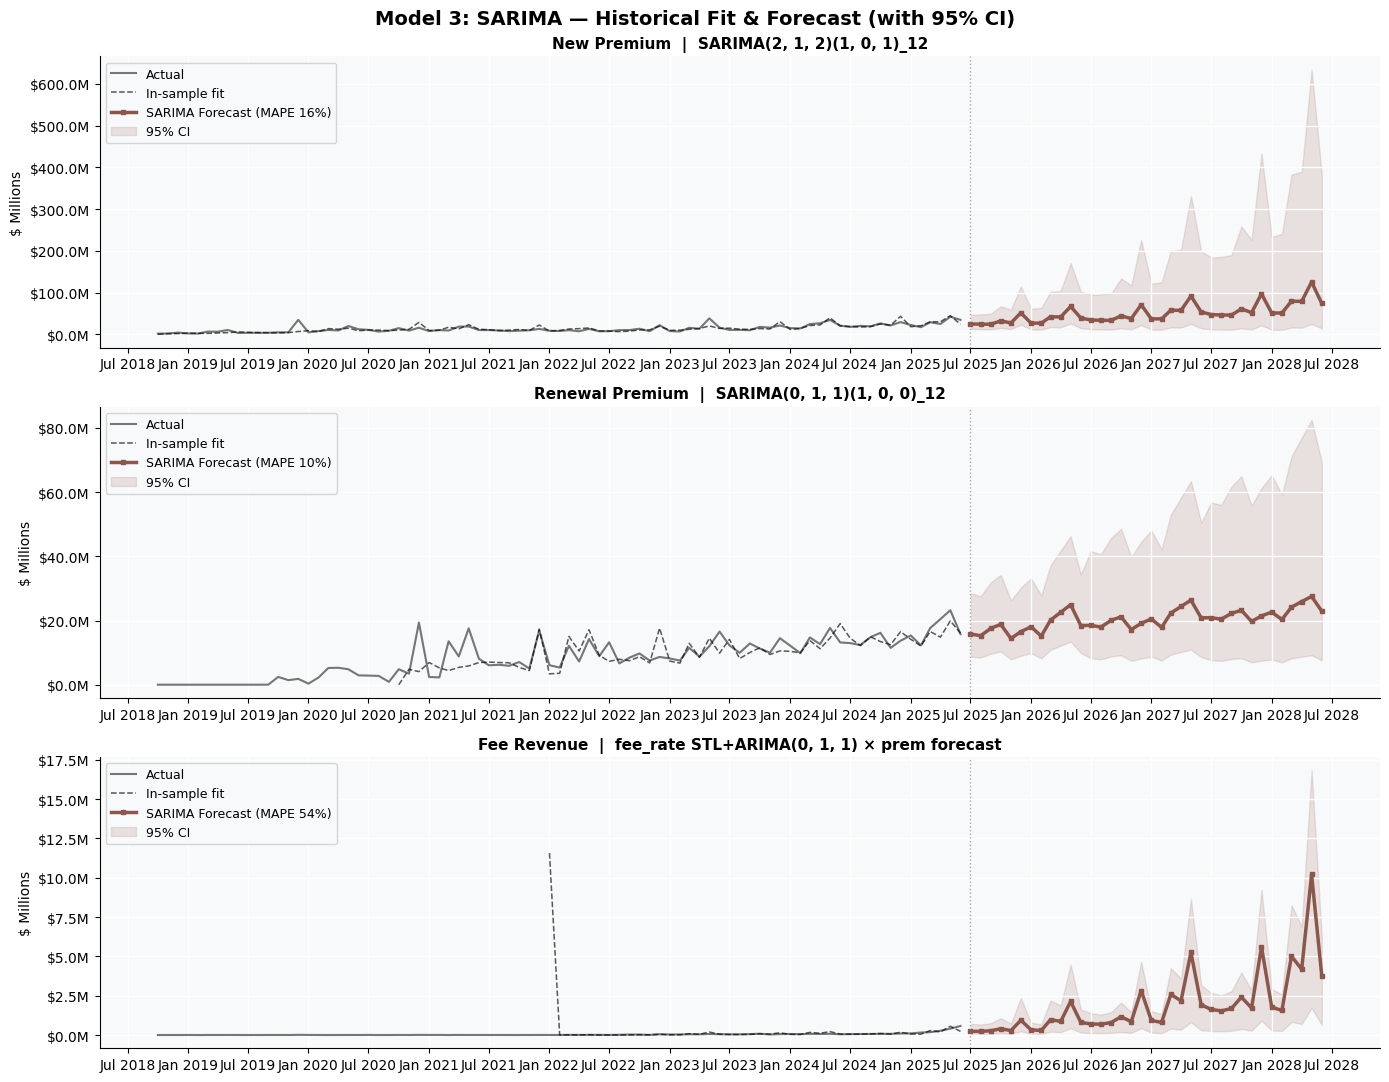

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
fig.suptitle('Model 3: SARIMA — Historical Fit & Forecast (with 95% CI)', fontsize=14, fontweight='bold')

for ax, (col, label, color) in zip(axes, SERIES_CFG):
    d = sarima_results[col]
    ax.plot(HIST_DATES, monthly[col]/1e6, color='#555555', linewidth=1.5, label='Actual', alpha=0.8)
    in_dates = d['in_sample_dates']
    ax.plot(in_dates, d['in_sample']/1e6, color='black', linewidth=1.1,
            linestyle='--', label='In-sample fit', alpha=0.65)
    ax.plot(FUTURE_DATES, d['forecast']/1e6, color=MODEL_COLORS['SARIMA'], linewidth=2.5,
            marker='s', markersize=3, label=f'SARIMA Forecast (MAPE {d["mape"]:.0f}%)')
    ax.fill_between(FUTURE_DATES, d['forecast_lo']/1e6, d['forecast_hi']/1e6,
                    color=MODEL_COLORS['SARIMA'], alpha=0.15, label='95% CI')
    ax.axvline(x=FUTURE_DATES[0], color='gray', linewidth=1, linestyle=':', alpha=0.7)
    if col == 'fees':
        order_str = f'fee_rate STL+ARIMA{d["order"]} × prem forecast'
    else:
        order_str = f'SARIMA{d["order"]}{d["seasonal_order"][:3]}_12'
    ax.set_title(f'{label}  |  {order_str}', fontsize=11, fontweight='bold')
    ax.set_ylabel('$ Millions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Comparison

In [12]:
# Build a single aligned forecast DataFrame for the common horizon
# Prophet: aligned to Jul 2025 - May 2028 (35 months), SARIMA/LSTM: 36 months
# For comparison tables, use the 35-month overlap

common_end   = min(prophet_fore_aligned.index[-1], FUTURE_DATES[-1])
common_dates = pd.date_range(start=FUTURE_DATES[0], end=common_end, freq='MS')

def align_to_common(arr, full_dates, common):
    s = pd.Series(arr, index=full_dates)
    return s.reindex(common).values

comp = pd.DataFrame(index=common_dates)
for col, label, _ in SERIES_CFG:
    comp[f'{col}_prophet'] = align_to_common(
        prophet_fore_aligned[col].values, prophet_fore_aligned.index, common_dates)
    comp[f'{col}_lstm']    = align_to_common(
        lstm_results[col]['forecast'], FUTURE_DATES, common_dates)
    comp[f'{col}_sarima']  = align_to_common(
        sarima_results[col]['forecast'], FUTURE_DATES, common_dates)

print(f'Comparison window: {common_dates[0].strftime("%b %Y")} to {common_dates[-1].strftime("%b %Y")}'
      f' ({len(common_dates)} months)')

Comparison window: Jul 2025 to Jun 2028 (36 months)


In [13]:
# Annual comparison table
comp_ann = comp.copy()
comp_ann['year'] = comp_ann.index.year

rows = []
for yr, grp in comp_ann.groupby('year'):
    for col, label, _ in SERIES_CFG:
        rows.append({
            'Year': yr, 'Series': label,
            'Prophet':   grp[f'{col}_prophet'].sum(),
            'STL+LSTM':  grp[f'{col}_lstm'].sum(),
            'SARIMA':    grp[f'{col}_sarima'].sum(),
        })

comp_tbl = pd.DataFrame(rows)

def fmt_m(x):
    return f'${x/1e6:.1f}M' if pd.notna(x) else '-'

print('Annual Forecast Comparison by Series')
print('=' * 75)
for (yr, ser), grp in comp_tbl.groupby(['Year','Series']):
    row = grp.iloc[0]
    print(f'  {yr}  {ser:22s}  Prophet: {fmt_m(row["Prophet"]):>9}  '
          f'STL+LSTM: {fmt_m(row["STL+LSTM"]):>9}  SARIMA: {fmt_m(row["SARIMA"]):>9}')
    if ser == 'Renewal Premium':
        print()

Annual Forecast Comparison by Series
  2025  Fee Revenue             Prophet:     $2.3M  STL+LSTM:     $4.4M  SARIMA:     $2.4M
  2025  New Premium             Prophet:   $176.4M  STL+LSTM:   $122.8M  SARIMA:   $184.8M
  2025  Renewal Premium         Prophet:   $101.8M  STL+LSTM:   $107.8M  SARIMA:    $98.4M

  2026  Fee Revenue             Prophet:     $9.3M  STL+LSTM:    $14.9M  SARIMA:    $12.4M
  2026  New Premium             Prophet:   $458.7M  STL+LSTM:   $292.0M  SARIMA:   $498.2M
  2026  Renewal Premium         Prophet:   $231.3M  STL+LSTM:   $244.5M  SARIMA:   $233.2M

  2027  Fee Revenue             Prophet:    $12.4M  STL+LSTM:    $22.3M  SARIMA:    $28.2M
  2027  New Premium             Prophet:   $573.9M  STL+LSTM:   $364.4M  SARIMA:   $685.4M
  2027  Renewal Premium         Prophet:   $269.6M  STL+LSTM:   $308.8M  SARIMA:   $260.0M

  2028  Fee Revenue             Prophet:     $6.5M  STL+LSTM:    $18.4M  SARIMA:    $26.5M
  2028  New Premium             Prophet:   $345.5M

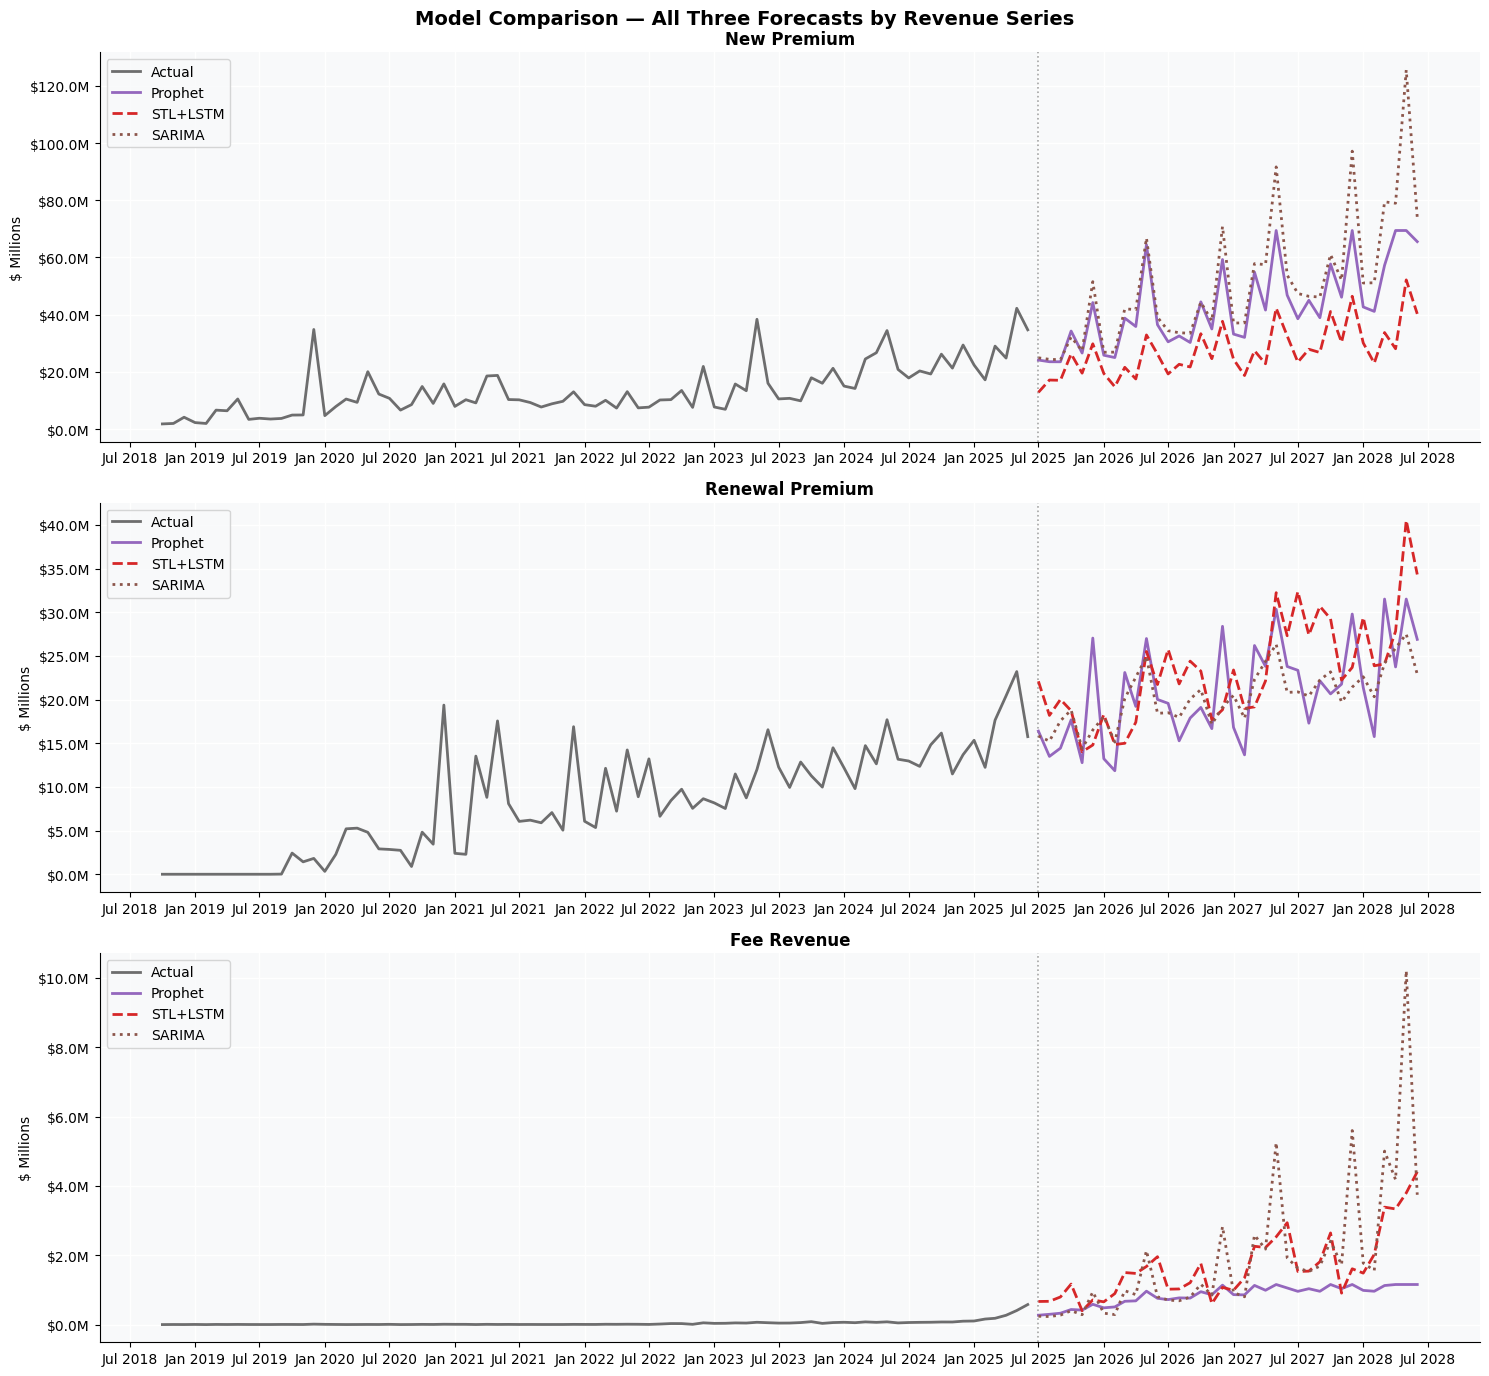

In [14]:
# Topline comparison chart — all three models on same axes
topline_comp = pd.DataFrame(index=common_dates)
topline_comp['Prophet']   = comp['new_premium_prophet'] + comp['renewal_premium_prophet'] + comp['fees_prophet']
topline_comp['STL+LSTM']  = comp['new_premium_lstm']    + comp['renewal_premium_lstm']    + comp['fees_lstm']
topline_comp['SARIMA']    = comp['new_premium_sarima']  + comp['renewal_premium_sarima']  + comp['fees_sarima']

fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle('Model Comparison — All Three Forecasts by Revenue Series', fontsize=14, fontweight='bold')

for ax, (col, label, color) in zip(axes, SERIES_CFG):
    # Actual history
    ax.plot(HIST_DATES, monthly[col]/1e6, color='#555555', linewidth=2,
            label='Actual', alpha=0.85, zorder=5)
    ax.axvline(x=FUTURE_DATES[0], color='gray', linewidth=1.2, linestyle=':', alpha=0.7)

    # Three model forecasts
    ax.plot(common_dates, comp[f'{col}_prophet']/1e6,
            color=MODEL_COLORS['Prophet'],  linewidth=2, linestyle='-',  label='Prophet')
    ax.plot(common_dates, comp[f'{col}_lstm']/1e6,
            color=MODEL_COLORS['STL+LSTM'], linewidth=2, linestyle='--', label='STL+LSTM')
    ax.plot(common_dates, comp[f'{col}_sarima']/1e6,
            color=MODEL_COLORS['SARIMA'],   linewidth=2, linestyle=':',  label='SARIMA')

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('$ Millions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

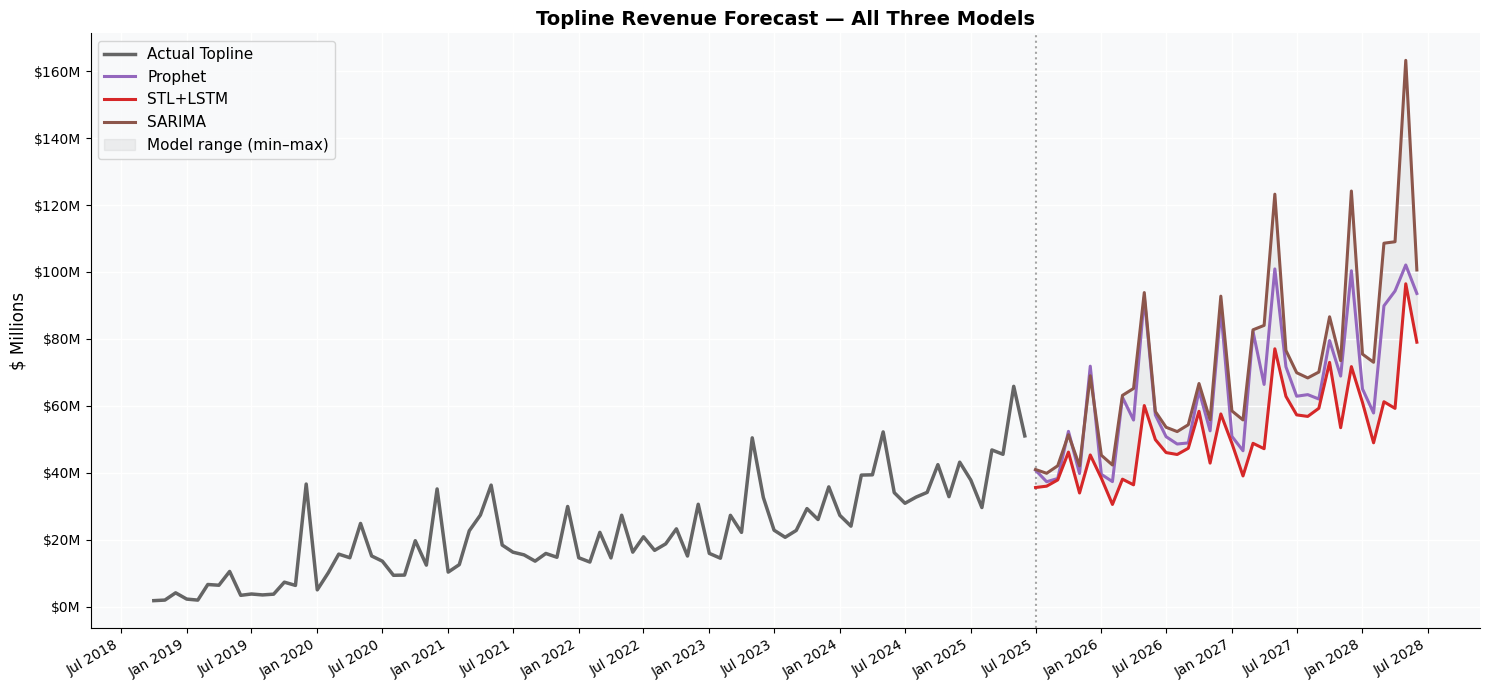

In [15]:
# Topline overlay — single chart, all 3 models
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(HIST_DATES, monthly['topline_revenue']/1e6, color='#555555', linewidth=2.5,
        label='Actual Topline', alpha=0.9, zorder=5)
ax.axvline(x=FUTURE_DATES[0], color='gray', linewidth=1.5, linestyle=':', alpha=0.7)

for name, vals in [('Prophet',  topline_comp['Prophet']),
                   ('STL+LSTM', topline_comp['STL+LSTM']),
                   ('SARIMA',   topline_comp['SARIMA'])]:
    ax.plot(common_dates, vals/1e6, color=MODEL_COLORS[name], linewidth=2.2,
            linestyle='-', label=name)

ax.fill_between(common_dates,
                topline_comp.min(axis=1)/1e6,
                topline_comp.max(axis=1)/1e6,
                alpha=0.10, color='gray', label='Model range (min–max)')

ax.set_title('Topline Revenue Forecast — All Three Models', fontsize=14, fontweight='bold')
ax.set_ylabel('$ Millions', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('topline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ensemble Forecast

### Weighting Strategy: Equal Weights (1/3 per model)

Each model receives equal weight (1/3) in the ensemble.

**Why equal weights?**
- Estimating Prophet's out-of-sample MAPE requires withholding data that Prophet was not trained
  on — but Prophet is trained inline on the same dataset, so a fair holdout comparison would
  require a full refitting cycle. Equal weights avoid this bias.
- Equal weighting is a well-established, robust baseline; it is the method recommended by the
  M4 forecasting competition when model quality is uncertain
- Each model captures genuinely different dynamics (Bayesian / neural / statistical), so equal
  averaging reduces model-specific bias without over-fitting to held-out MAPE noise

**Why this ensemble?**
- No single model is universally best; each has blind spots
- Prophet handles structural breaks well but may overfit recent fee acceleration
- STL+LSTM captures non-linear seasonality but has residual drift risk
- SARIMA is conservative and statistically principled but assumes linearity in log-space
- Their errors tend to be *partially independent* — averaging them cancels out model-specific noise

In [16]:
# Validation MAPEs — STL+LSTM and SARIMA are evaluated on a 12-month holdout.
# Prophet MAPE is estimated from in-sample fit on its own training window (not a true holdout),
# so it is shown for reference only.
mapes = {}
for col, label, _ in SERIES_CFG:
    mapes[col] = {
        'STL+LSTM': lstm_results[col]['mape'],
        'SARIMA':   sarima_results[col]['mape'],
    }

print('Validation MAPEs (last 12 months holdout):')
print(f'  {"Series":22s}  {"STL+LSTM":>10}  {"SARIMA":>10}  {"Prophet":>22}')
print('-' * 72)
for col, label, _ in SERIES_CFG:
    m = mapes[col]
    print(f'  {label:22s}  {m["STL+LSTM"]:>9.1f}%  {m["SARIMA"]:>9.1f}%  {"(in-sample only, not comparable)":>22}')

Validation MAPEs (last 12 months holdout):
  Series                    STL+LSTM      SARIMA                 Prophet
------------------------------------------------------------------------
  New Premium                  32.0%       16.2%  (in-sample only, not comparable)
  Renewal Premium              13.5%        9.9%  (in-sample only, not comparable)
  Fee Revenue                  36.6%       54.1%  (in-sample only, not comparable)


In [17]:
# Equal weights: 1/3 per model per series
weights = {}
for col, label, _ in SERIES_CFG:
    weights[col] = {'Prophet': 1/3, 'STL+LSTM': 1/3, 'SARIMA': 1/3}

print('Ensemble weights (equal weighting):')
print(f'  {"Series":22s}  {"Prophet":>10}  {"STL+LSTM":>10}  {"SARIMA":>10}')
print('-' * 60)
for col, label, _ in SERIES_CFG:
    w = weights[col]
    print(f'  {label:22s}  {w["Prophet"]:>9.1%}  {w["STL+LSTM"]:>9.1%}  {w["SARIMA"]:>9.1%}')

Ensemble weights (equal weighting):
  Series                     Prophet    STL+LSTM      SARIMA
------------------------------------------------------------
  New Premium                 33.3%      33.3%      33.3%
  Renewal Premium             33.3%      33.3%      33.3%
  Fee Revenue                 33.3%      33.3%      33.3%


In [18]:
# Build ensemble forecast
ensemble = pd.DataFrame(index=common_dates)
for col, label, _ in SERIES_CFG:
    w  = weights[col]
    p  = comp[f'{col}_prophet'].values
    l  = comp[f'{col}_lstm'].values
    s  = comp[f'{col}_sarima'].values
    ensemble[col] = w['Prophet']*p + w['STL+LSTM']*l + w['SARIMA']*s

ensemble['total_premium']   = ensemble['new_premium'] + ensemble['renewal_premium']
ensemble['topline_revenue'] = ensemble['total_premium'] + ensemble['fees']

# Annual summary
ens_ann = ensemble.copy()
ens_ann['year'] = ens_ann.index.year
ens_sum = ens_ann.groupby('year')[['new_premium','renewal_premium','fees',
                                    'total_premium','topline_revenue']].sum()
ens_sum.columns = ['New Premium','Renewal Premium','Fee Revenue','Total Premium','Topline Revenue']
print('Ensemble Annual Forecast')
print('=' * 75)
print(ens_sum.map(lambda x: f'${x/1e6:.1f}M').to_string())

Ensemble Annual Forecast
     New Premium Renewal Premium Fee Revenue Total Premium Topline Revenue
year                                                                      
2025     $161.4M         $102.7M       $3.0M       $264.0M         $267.1M
2026     $416.3M         $236.3M      $12.2M       $652.6M         $664.8M
2027     $541.2M         $279.5M      $21.0M       $820.7M         $841.7M
2028     $337.7M         $158.1M      $17.2M       $495.8M         $512.9M


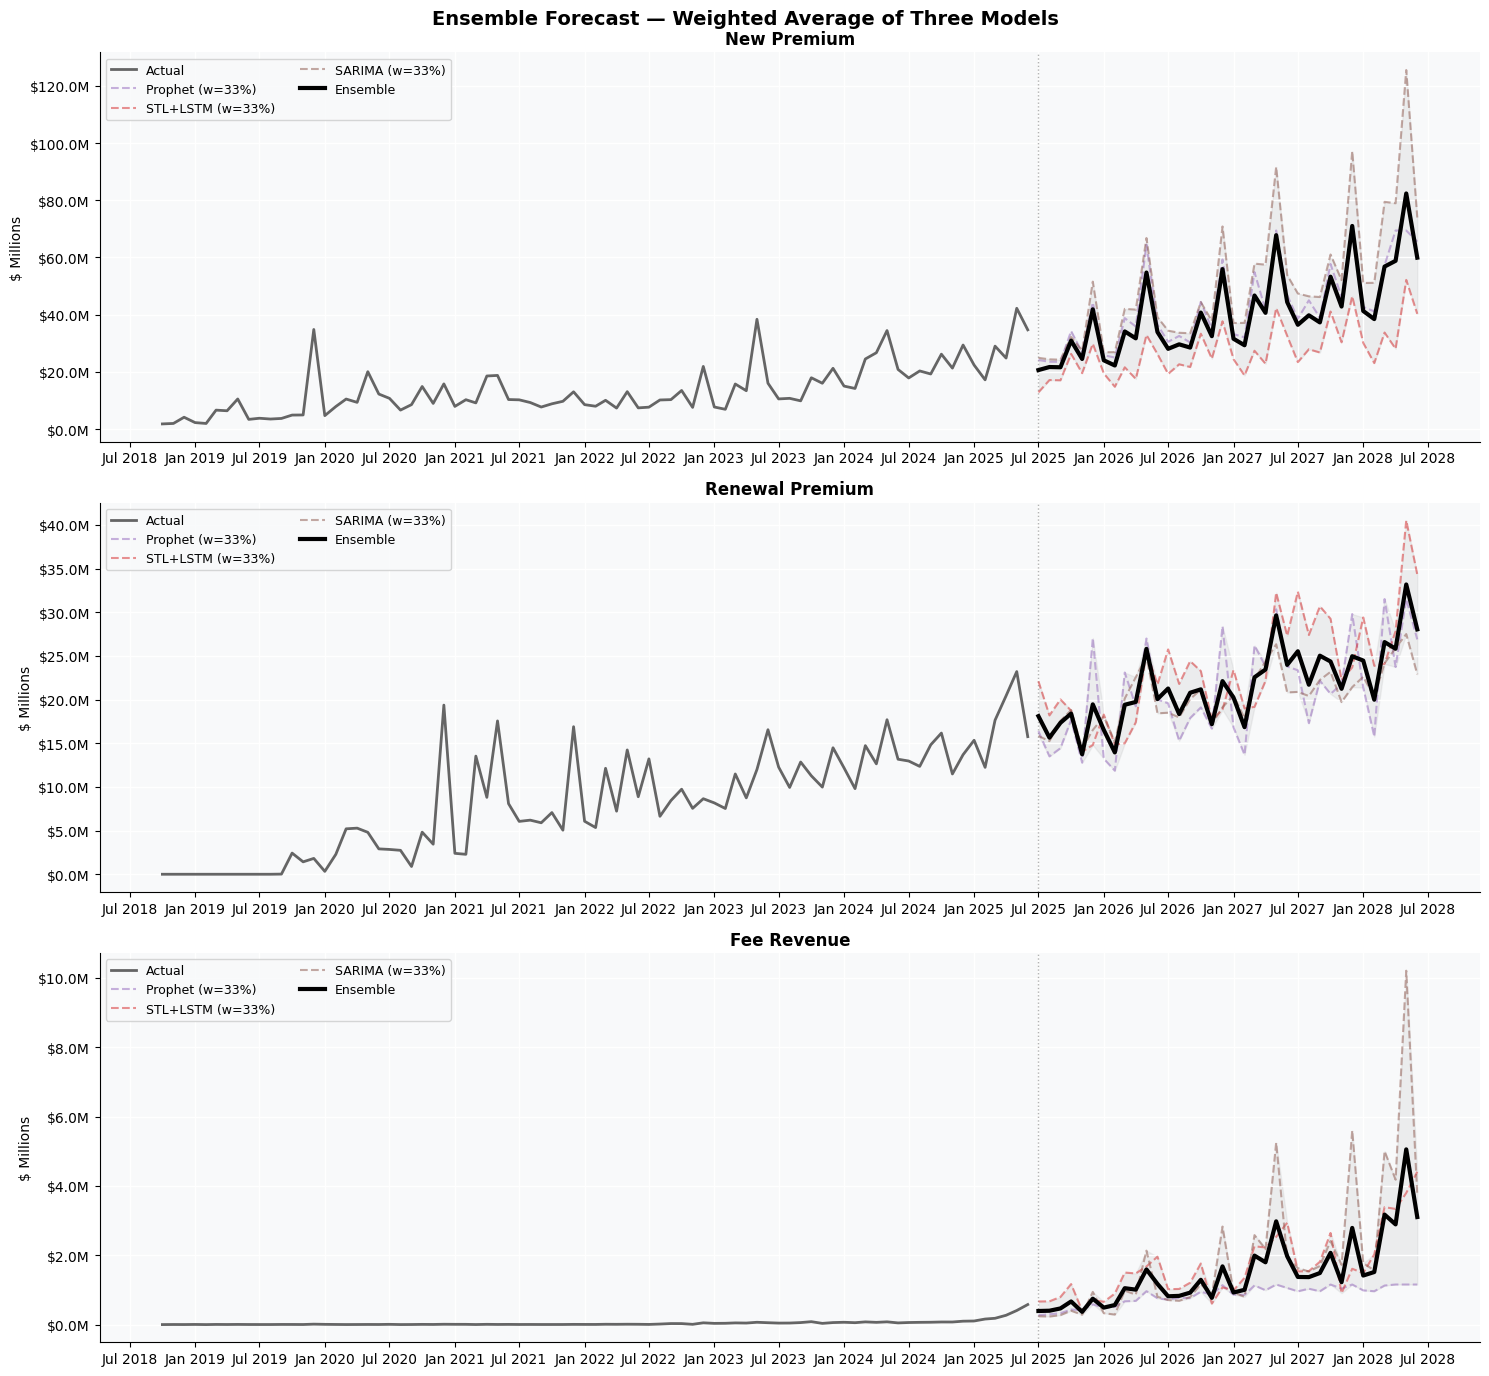

In [19]:
# Grand ensemble chart: history + all 3 models (faded) + ensemble (bold)
fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle('Ensemble Forecast — Weighted Average of Three Models', fontsize=14, fontweight='bold')

for ax, (col, label, color) in zip(axes, SERIES_CFG):
    ax.plot(HIST_DATES, monthly[col]/1e6, color='#555555', linewidth=2,
            label='Actual', alpha=0.9, zorder=5)
    ax.axvline(x=FUTURE_DATES[0], color='gray', linewidth=1, linestyle=':', alpha=0.6)
    w = weights[col]
    for name, fc_col in [('Prophet', f'{col}_prophet'),
                          ('STL+LSTM', f'{col}_lstm'),
                          ('SARIMA', f'{col}_sarima')]:
        ax.plot(common_dates, comp[fc_col]/1e6, color=MODEL_COLORS[name],
                linewidth=1.5, linestyle='--', alpha=0.5,
                label=f'{name} (w={w[name]:.0%})')
    ax.plot(common_dates, ensemble[col]/1e6, color='black', linewidth=3,
            label='Ensemble', zorder=10)
    ax.fill_between(common_dates,
                    comp[[f'{col}_prophet', f'{col}_lstm', f'{col}_sarima']].min(axis=1)/1e6,
                    comp[[f'{col}_prophet', f'{col}_lstm', f'{col}_sarima']].max(axis=1)/1e6,
                    alpha=0.10, color='gray')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('$ Millions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.legend(loc='upper left', fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('ensemble_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Final Summary & Tables

In [20]:
# Monthly ensemble forecast table
disp = ensemble[['new_premium','renewal_premium','fees','total_premium','topline_revenue']].copy()
disp.columns = ['New Premium','Renewal Premium','Fee Revenue','Total Premium','Topline Revenue']
disp.index = disp.index.strftime('%b %Y')
print('Monthly Ensemble Revenue Forecast')
print('=' * 95)
print(disp.map(lambda x: f'${x/1e6:.2f}M').to_string())

Monthly Ensemble Revenue Forecast
         New Premium Renewal Premium Fee Revenue Total Premium Topline Revenue
Jul 2025     $20.65M         $18.10M      $0.39M       $38.76M         $39.15M
Aug 2025     $21.72M         $15.64M      $0.40M       $37.36M         $37.76M
Sep 2025     $21.64M         $17.34M      $0.47M       $38.98M         $39.44M
Oct 2025     $30.93M         $18.40M      $0.67M       $49.33M         $50.00M
Nov 2025     $24.53M         $13.73M      $0.37M       $38.27M         $38.63M
Dec 2025     $41.88M         $19.45M      $0.75M       $61.33M         $62.07M
Jan 2026     $24.07M         $16.52M      $0.49M       $40.59M         $41.08M
Feb 2026     $22.26M         $13.95M      $0.56M       $36.21M         $36.77M
Mar 2026     $34.15M         $19.41M      $1.05M       $53.56M         $54.61M
Apr 2026     $31.74M         $19.73M      $1.01M       $51.47M         $52.47M
May 2026     $54.74M         $25.80M      $1.59M       $80.54M         $82.13M
Jun 2026     $33.9

In [21]:
# Side-by-side annual comparison: all models + ensemble
ens_ann_c = ensemble.copy(); ens_ann_c['year'] = ens_ann_c.index.year
top_ens = ens_ann_c.groupby('year')['topline_revenue'].sum()

p_ann_c = topline_comp.copy(); p_ann_c['year'] = p_ann_c.index.year
top_prophet  = p_ann_c.groupby('year')['Prophet'].sum()
top_lstm     = p_ann_c.groupby('year')['STL+LSTM'].sum()
top_sarima   = p_ann_c.groupby('year')['SARIMA'].sum()

topline_ann = pd.DataFrame({
    'Prophet':  top_prophet,
    'STL+LSTM': top_lstm,
    'SARIMA':   top_sarima,
    'Ensemble': top_ens,
})

print('Annual Topline Revenue — All Models vs Ensemble')
print('=' * 70)
print(topline_ann.map(lambda x: f'${x/1e6:.1f}M').to_string())
print()
base_2024 = monthly[monthly.index.year==2024]['topline_revenue'].sum()
print(f'2024 Actual Topline: ${base_2024/1e6:.1f}M')
print()
print('YoY vs 2024 Actuals:')
print((topline_ann.div(base_2024) - 1).map(lambda x: f'{x*100:+.1f}%').to_string())

Annual Topline Revenue — All Models vs Ensemble
      Prophet STL+LSTM   SARIMA Ensemble
year                                    
2025  $280.6M  $235.1M  $285.5M  $267.1M
2026  $699.3M  $551.4M  $743.8M  $664.8M
2027  $855.9M  $695.6M  $973.6M  $841.7M
2028  $502.8M  $406.0M  $629.9M  $512.9M

2024 Actual Topline: $432.9M

YoY vs 2024 Actuals:
     Prophet STL+LSTM   SARIMA Ensemble
year                                   
2025  -35.2%   -45.7%   -34.0%   -38.3%
2026  +61.5%   +27.4%   +71.8%   +53.6%
2027  +97.7%   +60.7%  +124.9%   +94.4%
2028  +16.2%    -6.2%   +45.5%   +18.5%


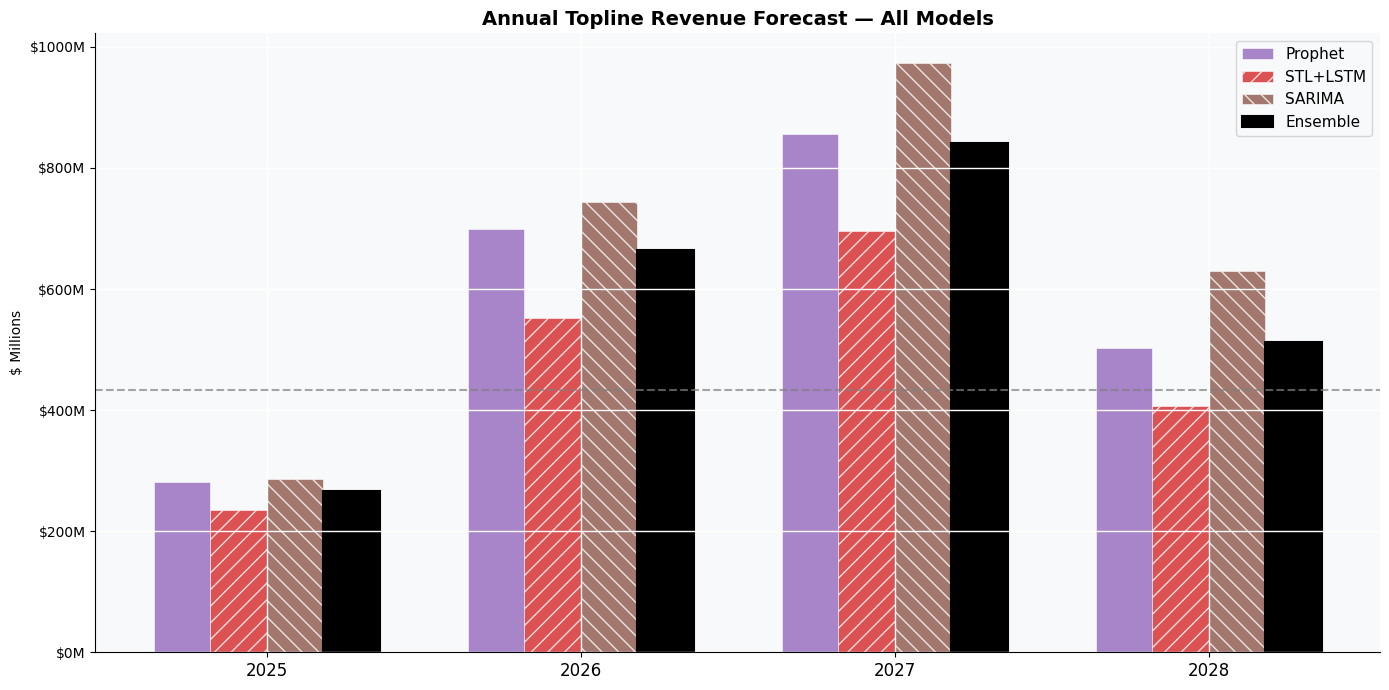

In [22]:
# Final bar chart: annual comparison across all models
fig, ax = plt.subplots(figsize=(14, 7))
bar_data = topline_ann.copy()
x = np.arange(len(bar_data))
w = 0.18
model_bar_colors = ['#9467bd', '#d62728', '#8c564b', '#000000']
hatches = ['', '//', '\\\\', '']

for i, (model, mcolor, hatch) in enumerate(zip(bar_data.columns, model_bar_colors, hatches)):
    offset = (i - 1.5) * w
    ax.bar(x + offset, bar_data[model]/1e6, w,
           color=mcolor, alpha=0.8 if model != 'Ensemble' else 1.0,
           hatch=hatch, label=model,
           edgecolor='white' if model != 'Ensemble' else 'black',
           linewidth=1.5 if model == 'Ensemble' else 0.5)

ax.set_xticks(x)
ax.set_xticklabels([f'{yr}' for yr in bar_data.index], fontsize=12)
ax.set_title('Annual Topline Revenue Forecast — All Models', fontsize=14, fontweight='bold')
ax.set_ylabel('$ Millions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.legend(fontsize=11)
# Add 2024 actual reference line
ax.axhline(y=base_2024/1e6, color='gray', linestyle='--', linewidth=1.5,
           alpha=0.7, label='2024 Actual')
plt.tight_layout()
plt.savefig('annual_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Final summary console output
print('=' * 75)
print('ENSEMBLE FORECAST SUMMARY  (Jul 2025 – May 2028)')
print('=' * 75)
print(f'  {"Year":<8} {"New Prem":>14} {"Renewal":>14} {"Fees":>12} {"Topline":>14}')
print('-' * 75)
for yr, row in ens_sum.iterrows():
    note = '  (H2 only)' if yr == 2025 else ('  (H1 only)' if yr == 2028 else '')
    print(f'  {yr:<8} ${row["New Premium"]/1e6:>12.1f}M '
          f'${row["Renewal Premium"]/1e6:>12.1f}M '
          f'${row["Fee Revenue"]/1e6:>10.1f}M '
          f'${row["Topline Revenue"]/1e6:>12.1f}M{note}')
print('-' * 75)
tot = ens_sum.sum()
print(f'  {"3yr Sum":<8} ${tot["New Premium"]/1e6:>12.1f}M '
      f'${tot["Renewal Premium"]/1e6:>12.1f}M '
      f'${tot["Fee Revenue"]/1e6:>10.1f}M '
      f'${tot["Topline Revenue"]/1e6:>12.1f}M')
print()
h25 = monthly[monthly.index.year == 2025]['topline_revenue'].sum()
f25 = ensemble[ensemble.index.year == 2025]['topline_revenue'].sum()
print(f'2024 Actual full year:                    ${base_2024/1e6:.1f}M')
print(f'2025 Blended (Jan-Jun actual + H2 ens.):  ${(h25+f25)/1e6:.1f}M  ({(h25+f25)/base_2024-1:+.1%} vs 2024)')
print()
print('Validation MAPEs (last 12 months of training history):')
print(f'  {"Series":22s}  {"STL+LSTM":>10}  {"SARIMA":>10}  {"Prophet":>22}')
print('-' * 75)
for col, label, _ in SERIES_CFG:
    m = mapes[col]
    print(f'  {label:22s}  {m["STL+LSTM"]:>9.1f}%  {m["SARIMA"]:>9.1f}%  {"(in-sample only)":>22}')

ENSEMBLE FORECAST SUMMARY  (Jul 2025 – May 2028)
  Year           New Prem        Renewal         Fees        Topline
---------------------------------------------------------------------------
  2025     $       161.4M $       102.7M $       3.0M $       267.1M  (H2 only)
  2026     $       416.3M $       236.3M $      12.2M $       664.8M
  2027     $       541.2M $       279.5M $      21.0M $       841.7M
  2028     $       337.7M $       158.1M $      17.2M $       512.9M  (H1 only)
---------------------------------------------------------------------------
  3yr Sum  $      1456.6M $       776.5M $      53.3M $      2286.5M

2024 Actual full year:                    $432.9M
2025 Blended (Jan-Jun actual + H2 ens.):  $543.8M  (+25.6% vs 2024)

Validation MAPEs (last 12 months of training history):
  Series                    STL+LSTM      SARIMA                 Prophet
---------------------------------------------------------------------------
  New Premium                  32.0%   